## Duolingo Option Pricing using BlackScholesModel

In [3]:
import yfinance as yf
import numpy as np
import pandas as pd
import scipy.stats as si
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from datetime import datetime
from datetime import date

In [4]:
def  GetOptionData(symbol):
    ticker = yf.Ticker(symbol)
    #options is a yfinance function used for options expirations
    OptionsDates = ticker.options
    # using the closest expiry date for the analysis
    OptionsData = ticker.option_chain(OptionsDates[0])
    return OptionsData.calls , OptionsData.puts

DUOLcalls , DUOLputs = GetOptionData('DUOL')
DUOLcalls, DUOLputs

(         contractSymbol             lastTradeDate  strike  lastPrice    bid  \
 0   DUOL250822C00290000 2025-08-14 17:37:53+00:00   290.0      46.50  40.50   
 1   DUOL250822C00300000 2025-08-20 14:01:00+00:00   300.0      26.00  31.30   
 2   DUOL250822C00305000 2025-08-18 15:49:14+00:00   305.0      60.00  26.40   
 3   DUOL250822C00310000 2025-08-19 18:44:27+00:00   310.0      33.70  21.90   
 4   DUOL250822C00315000 2025-08-19 13:30:32+00:00   315.0      50.10  18.10   
 5   DUOL250822C00320000 2025-08-20 15:47:41+00:00   320.0      13.60  14.90   
 6   DUOL250822C00325000 2025-08-20 14:26:29+00:00   325.0      10.50  11.20   
 7   DUOL250822C00330000 2025-08-20 15:44:38+00:00   330.0       7.26   8.20   
 8   DUOL250822C00335000 2025-08-20 15:55:13+00:00   335.0       5.30   5.20   
 9   DUOL250822C00340000 2025-08-20 16:07:33+00:00   340.0       3.80   3.90   
 10  DUOL250822C00345000 2025-08-20 15:25:35+00:00   345.0       2.20   2.50   
 11  DUOL250822C00350000 2025-08-20 16:0

/tmp/ipython-input-259614007.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  DUOLstockData =  yf.download('DUOL', StartDate, Today)
[*********************100%***********************]  1 of 1 completed


Text(0, 0.5, 'Stock Price (USD)')

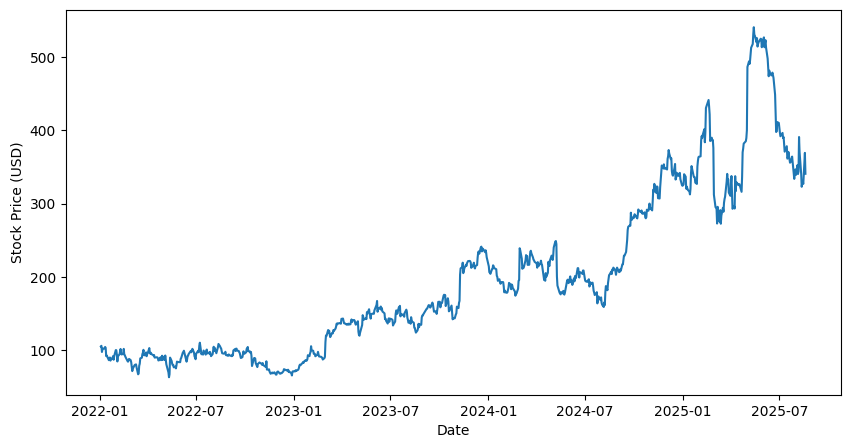

In [5]:
Today = date.today()
StartDate = '2022-01-01'
DUOLstockData =  yf.download('DUOL', StartDate, Today)

# plotting the option data
plt.figure( figsize=(10,5))
plt.plot(DUOLstockData["Close"])
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
# plt.grid(True)

In [9]:
# Defining the Black Scholes Model

class BlackScholesModel:
    def __init__(self,S,K,t,r,sigma):
        self.K = K  # strike price
        self.S = S  # stock price
        self.t = t  # time to expiration
        self.r = r  # risk free rate
        self.sigma = sigma  # volatility

    def d1(self):
        return (np.log(self.S /self.K)  + (self.r + 0.5 * self.sigma **2)* self.t)/(self.sigma * np.sqrt(self.t))

    def d2(self):
        return  self.d1() - self.sigma * np.sqrt(self.t)

    def CallOptionPrice(self):
        return  (self.S * si.norm.cdf(self.d1(), 0.0 ,1.0) - self.K * np.exp(-self.r * self.t)*si.norm.cdf(self.d2(),  0.0, 1.0))

    def PutOptionPrice(self):
        return (self.K * np.exp(-self.r * self.t) *si.norm.cdf(-self.d2(), 0.0,1.0) - self.S * si.norm.cdf(-self.d1()  ,0.0, 1.0))


bsm = BlackScholesModel(S = 100, K = 100, t = 1,r = 0.05, sigma =  0.2)
print(bsm.CallOptionPrice())
print(bsm.PutOptionPrice())

10.450583572185565
5.573526022256971


In [8]:
# function to calculate the volatility
def VolatalityCalculation(StockData ,window = 252  ):
    log_returns =  np.log(StockData["Close"].pct_change())
    volatility  = np.sqrt(window) *log_returns.std()
    return volatility

DUOLvolatility = VolatalityCalculation(DUOLstockData)
print(DUOLvolatility)

Ticker
DUOL    19.600138
dtype: float64


/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


In [10]:
class BlackScholesGreeks(BlackScholesModel):
    def DeltaCall(self):
        return si.norm.cdf(self.d1() , 0.0, 1.0)

    def DeltaPut(self):
        return -si.norm.cdf(-self.d1() , 0.0, 1.0)

    def Gamma(self):
        return (si.norm.pdf(self.d1(),0.0,1.0)/(self.sigma*self.S*np.sqrt(self.t)))

    def ThetaCall(self):
        return (-(self.S*self.sigma*si.norm.pdf(self.d1(),0.0,1.0)/ (2*np.sqrt(self.t))) - self.r*self.K.np.exp(-self.r*self.t)*si.norm.cdf(self.d2(),0.0,1.0))

    def ThetaPut(self):
        return (-(self.S*self.sigma*si.norm.pdf(self.d1(),0.0,1.0)/ (2*np.sqrt(self.t))) + self.r*self.K.np.exp(-self.r*self.t)*si.norm.cdf(-self.d2(),0.0,1.0))

    def Vega(self):
        return (self.S*np.sqrt(self.t)*si.norm.pdf(self.d1(),0.0,1.0))/100

    def RhoCall(self):
        return (self.K*self.t*np.exp(-self.r*self.t*si.norm.cdf(self.d2(),0.0,1.0)))/100

    def RhoPut(self):
        return -(self.K*self.t*np.exp(-self.r*self.t*si.norm.cdf(-self.d2(),0.0,1.0)))/100

bsg =BlackScholesGreeks( S= 100 ,  K =100,  t =1 ,r = 0.05,sigma =0.2)
print(bsg.DeltaCall())
print(bsg.DeltaPut())

0.6368306511756191
-0.3631693488243809


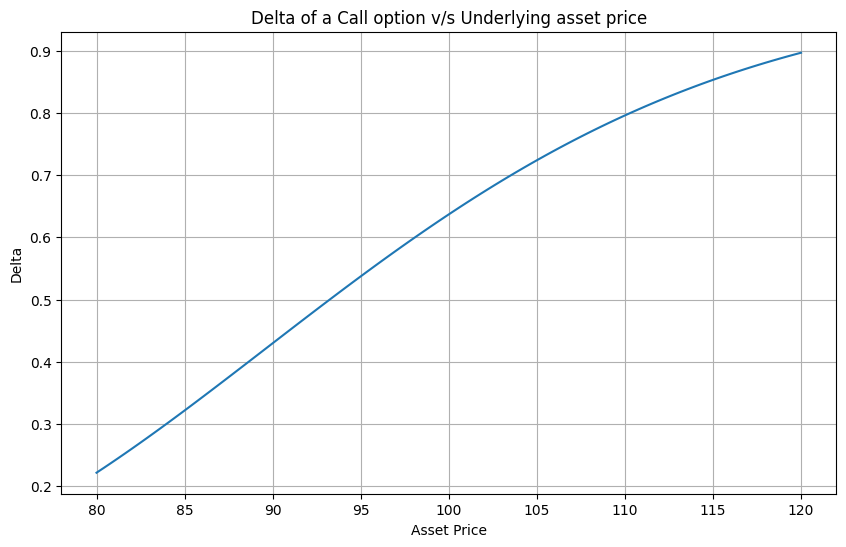

In [11]:
StockPrices =  np.linspace(80,120,100)
deltas = [BlackScholesGreeks(S =price,  K =100, t =1,r = 0.05,sigma = 0.2 ).DeltaCall() for price in  StockPrices]

plt.figure(figsize=(10,6))
plt.plot(StockPrices, deltas)
plt.title("Delta of a Call option v/s Underlying asset price")
plt.xlabel("Asset Price")
plt.ylabel("Delta")
plt.grid(True)

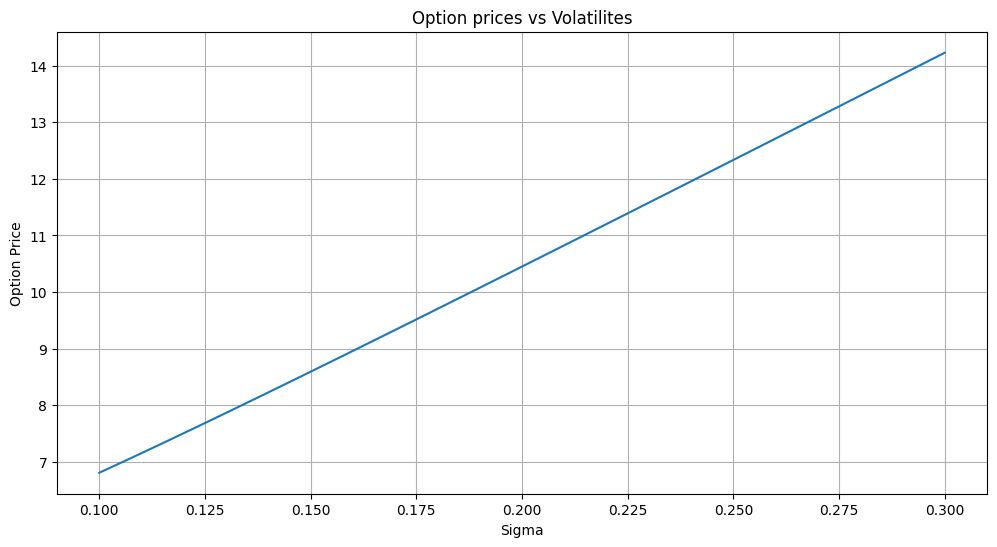

In [12]:
def PlotOptionSensitivity(BSmodel,  parameter, values, option_type = "call"):
    prices =  []
    for value in values:
        setattr(BSmodel,  parameter, value)
        if option_type == "call":
            prices.append(BSmodel.CallOptionPrice())
        else:
            prices.append(BSmodel.PutOptionPrice())

    plt.figure(figsize =(12,6))
    plt.plot(values , prices)
    plt.title("Option prices vs Volatilites")
    plt.xlabel("Sigma")
    plt.ylabel("Option Price")
    plt.grid(True)

volatilities = np.linspace(0.1,0.3,100)
PlotOptionSensitivity(bsm,"sigma" ,volatilities, "call")